R² (train): 0.8626
RMSE (train): 25.7147
Mean of Actual Values (train): 135.6860


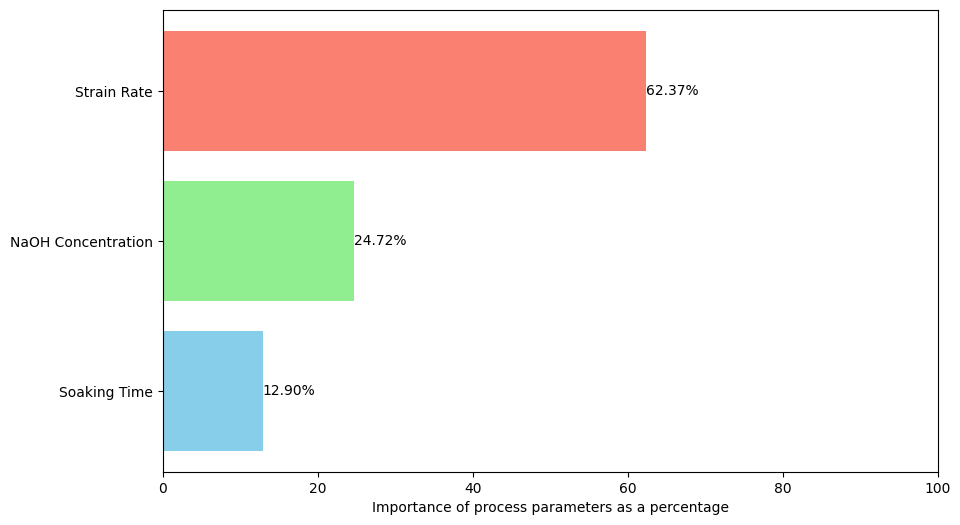

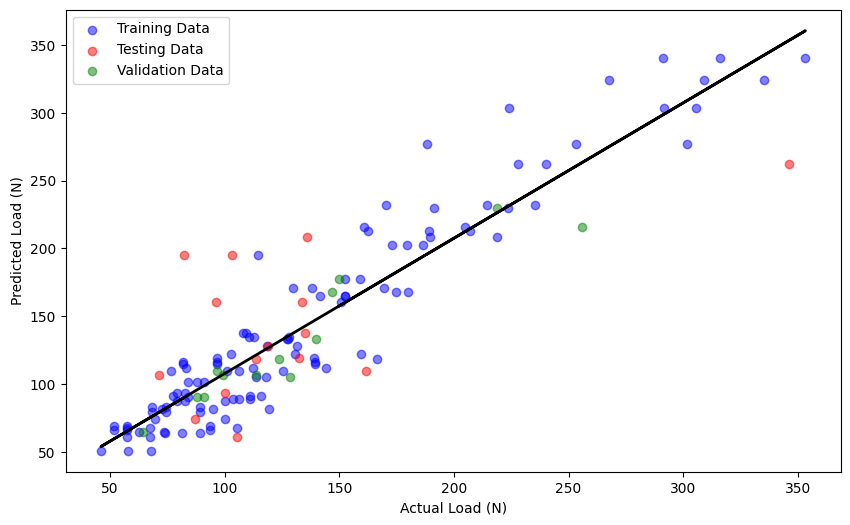

   Strain Rate  NaOH Concentration  Soaking Time  Predicted Load (N)
0     0.000333                  14            10          100.215104
1     0.000667                  14            10           99.445627
2     0.001000                  14            10           98.678455
3     0.001330                  14            10           97.918194
4     0.001670                  14            10          207.433648
5     0.002000                  14            10          206.673387
6     0.002330                  14            10          205.913126

=== OLS on process parameters ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     3.170
Date:                Mon, 08 Sep 2025   Prob (F-statistic):             0.0263
Time:             

AttributeError: 'PandasData' object has no attribute 'design_info'

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm

data = pd.read_excel('ensemble learning data.xlsx')
X = data[['Strain Rate', 'NaOH Concentration', 'Soaking Time']]
y = data['Load'].values.reshape(-1, 1)  # keep original units for reporting later

scaler = StandardScaler()
y_scaled = scaler.fit_transform(y).flatten()

X_temp, X_test, y_temp, y_test = train_test_split(X, y_scaled, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1, random_state=42)  # 0.125 of 80% = 10%

models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(random_state=42),
    'Ridge': Ridge(random_state=42)
}

val_predictions = pd.DataFrame()
for name, model in models.items():
    model.fit(X_train, y_train)
    val_predictions[name] = model.predict(X_val)

meta_learner = LinearRegression()
meta_learner.fit(val_predictions, y_val)
train_predictions = pd.DataFrame()
test_predictions  = pd.DataFrame()
val_predictions   = pd.DataFrame()
for name, model in models.items():
    train_predictions[name] = model.predict(X_train)
    test_predictions[name]  = model.predict(X_test)
    val_predictions[name]   = model.predict(X_val)

final_train_pred_scaled = meta_learner.predict(train_predictions)
final_test_pred_scaled  = meta_learner.predict(test_predictions)
final_val_pred_scaled   = meta_learner.predict(val_predictions)

final_train_pred = scaler.inverse_transform(final_train_pred_scaled.reshape(-1, 1)).flatten()
final_test_pred  = scaler.inverse_transform(final_test_pred_scaled.reshape(-1, 1)).flatten()
final_val_pred   = scaler.inverse_transform(final_val_pred_scaled.reshape(-1, 1)).flatten()

y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
y_test_orig  = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_val_orig   = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()

r2_train = r2_score(y_train_orig, final_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_orig, final_train_pred))
mean_actual_train = np.mean(y_train_orig)
print(f'R² (train): {r2_train:.4f}')
print(f'RMSE (train): {rmse_train:.4f}')
print(f'Mean of Actual Values (train): {mean_actual_train:.4f}')


dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
importances = dt.feature_importances_ * 100
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance (%)': importances})
feature_importance = feature_importance.sort_values(by='Importance (%)', ascending=True)
colors = ['skyblue', 'lightgreen', 'salmon']

plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance (%)'], color=colors)
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height() / 2, f'{width:.2f}%', va='center', ha='left')
plt.xlim(0, 100)
plt.xlabel('Importance of process parameters as a percentage')
plt.savefig('feature_importance_horizontal_colors.png', dpi=300, bbox_inches='tight')
plt.show()
combined_actual = np.concatenate([y_train_orig, y_test_orig, y_val_orig])
combined_pred   = np.concatenate([final_train_pred, final_test_pred, final_val_pred])
m, b = np.polyfit(combined_actual, combined_pred, 1)
best_fit_line = m * combined_actual + b

plt.figure(figsize=(10, 6))
plt.scatter(y_train_orig, final_train_pred, color='blue',  alpha=0.5, label='Training Data')
plt.scatter(y_test_orig,  final_test_pred,  color='red',   alpha=0.5, label='Testing Data')
plt.scatter(y_val_orig,   final_val_pred,   color='green', alpha=0.5, label='Validation Data')
plt.plot(combined_actual, best_fit_line, color='black', linewidth=2)
plt.xlabel('Actual Load (N)')
plt.ylabel('Predicted Load (N)')
plt.legend()
plt.savefig('predicted_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

output_train = pd.DataFrame({'Actual': y_train_orig, 'Predicted': final_train_pred, 'Split': 'Train'})
output_test  = pd.DataFrame({'Actual': y_test_orig,  'Predicted': final_test_pred,  'Split': 'Test'})
output_val   = pd.DataFrame({'Actual': y_val_orig,   'Predicted': final_val_pred,   'Split': 'Val'})
output = pd.concat([output_train, output_test, output_val], ignore_index=True)
output.to_excel('Main Predicted File.xlsx', index=False)


specific_points = pd.DataFrame({
    'Strain Rate': [0.000333,0.000667,0.001,0.00133,0.00167,0.002,0.00233],
    'NaOH Concentration': [14]*7,
    'Soaking Time': [10]*7
})
specific_preds_scaled = pd.DataFrame()
for name, model in models.items():
    specific_preds_scaled[name] = model.predict(specific_points)
final_specific_preds_scaled = meta_learner.predict(specific_preds_scaled)
final_specific_preds = scaler.inverse_transform(final_specific_preds_scaled.reshape(-1, 1)).flatten()
specific_points['Predicted Load (N)'] = final_specific_preds
specific_points.to_excel('specific_points_predictions_scaled.xlsx', index=False)
print(specific_points)

X_ols = sm.add_constant(X)               
y_ols = data['Load'].values              

ols_model = sm.OLS(y_ols, X_ols).fit()

print("\n=== OLS on process parameters ===")
print(ols_model.summary())
with open('OLS_process_parameters_summary.txt', 'w') as f:
    f.write(ols_model.summary().as_text())

anova_tbl = anova_lm(ols_model, typ=2)
print("\nANOVA (process parameters):")
print(anova_tbl)
anova_tbl.to_csv('OLS_process_parameters_ANOVA.csv', index=True)
param_stats = pd.DataFrame({
    'coef': ols_model.params,
    'std_err': ols_model.bse,
    't_value': ols_model.tvalues,
    'p_value': ols_model.pvalues
})
param_stats.to_csv('OLS_process_parameters_coef_t_p.csv')

do_meta_significance = True
if do_meta_significance:
    X_meta = sm.add_constant(val_predictions)       # base predictions on validation set
    y_meta = y_val                                  # meta-learner was trained on scaled y
    ols_meta = sm.OLS(y_meta, X_meta).fit()

    print("\n=== OLS on meta-learner inputs (base regressors) ===")
    print(ols_meta.summary())

    with open('OLS_meta_learner_summary.txt', 'w') as f:
        f.write(ols_meta.summary().as_text())

    anova_meta = anova_lm(ols_meta, typ=2)
    print("\nANOVA (meta-learner inputs):")
    print(anova_meta)
    anova_meta.to_csv('OLS_meta_learner_ANOVA.csv', index=True)
